# 최종 보고서 그래프

[`docs/final-report.md`](../docs/final-report.md)의 표 가운데 그래프로 보는 편이 직관적인 다섯 개를
그림으로 만들어 [`docs/figures/`](../docs/figures/)에 저장한다.

| 그림 | 원본 표 | 파일 이름 |
| ---- | ------- | --------- |
| 그림 4  | 표 9 — 에포크별 검증 손실           | `val-loss-curves` |
| 그림 5  | 표 11 — 8개 조합 전체 성능          | `overall-performance` |
| 그림 6  | 표 14 — 오차 거리 분포              | `error-distribution-all` |
| 그림 10 | 표 24-2 — 도구 수별 헝가리안 FN율   | `hungarian-fn-by-tool-count` |
| 그림 12 | 표 29·30 — 분할 방식별 성능 변화    | `split-unit-comparison` |

**입력은 전부 저장소 안의 실험 산출물이다.** 보고서의 수치를 옮겨 적지 않고
`data/models/<...>/metric.csv`, `data/results/<...>/summary.json`,
`data/results/<...>/per_tip.csv`에서 매번 다시 계산하므로, 재학습·재평가 후
`run generate-summary`와 함께 이 노트북을 다시 실행하면 그림도 갱신된다.
각 그림 셀은 계산한 값을 표와 대조할 수 있도록 함께 출력한다.

모델이나 데이터셋은 로드하지 않는다. GPU도 필요 없다.


In [1]:
from __future__ import annotations

import csv
import json
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

for candidate in (Path.cwd().resolve(), Path.cwd().resolve().parent):
    if (candidate / "ttd").is_dir():
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("Run the notebook from this repository or its notebook/ directory.")

MODELS_ROOT = REPO_ROOT / "data/models"
RESULTS_ROOT = REPO_ROOT / "data/results"
FIGURE_DIR = REPO_ROOT / "docs/figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# 표 11의 행 순서 그대로 8개 조합을 고정한다.
COMBINATIONS = [
    (dataset, target_mode, model_type)
    for dataset in ("erop", "cholec80")
    for target_mode in ("gradient-seg", "gaussian-tip")
    for model_type in ("monai", "monai_mini")
]

# docs/figures/README.md의 색 규약.
COLOR = {
    "gaussian-tip": "#2f6f9f",
    "gradient-seg": "#c4763a",
    "solo": "#3f8468",
    "shared": "#75619e",
    "miss": "#ac4b45",
}
GRID = "#d5d5d5"
INK = "#222222"

mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 192,          # docs/figures/README.md: PNG는 2배 해상도(192 dpi)
    "savefig.bbox": "tight",
    "svg.fonttype": "none",      # SVG에 텍스트를 텍스트로 남겨 편집 가능하게 둔다
    "font.family": ["Noto Sans CJK KR", "NanumGothic", "DejaVu Sans"],
    "font.monospace": ["D2Coding", "NanumGothicCoding", "DejaVu Sans Mono"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.edgecolor": "#888888",
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "axes.unicode_minus": False,
})


def mix(color: str, other: str, weight: float) -> str:
    """color를 other 쪽으로 weight만큼 섞은 hex 색을 돌려준다."""
    a = mpl.colors.to_rgb(color)
    b = mpl.colors.to_rgb(other)
    return mpl.colors.to_hex(tuple(x * (1 - weight) + y * weight for x, y in zip(a, b)))


def spread(values: list[float], min_gap: float) -> list[float]:
    """겹치는 라벨의 세로 위치를 min_gap 이상 벌린 좌표로 돌려준다(값 순서는 유지)."""
    order = sorted(range(len(values)), key=values.__getitem__)
    placed = list(values)
    for previous, current in zip(order, order[1:]):
        if placed[current] - placed[previous] < min_gap:
            placed[current] = placed[previous] + min_gap
    return placed


def save(fig, name: str) -> None:
    """SVG(원본)와 PNG(문서 삽입용)를 같은 이름으로 저장한다."""
    for suffix in ("svg", "png"):
        path = FIGURE_DIR / f"{name}.{suffix}"
        fig.savefig(path)
        print(f"saved {path.relative_to(REPO_ROOT)}")


## 데이터 로딩

세 종류의 실험 산출물만 읽는다.

- `metric.csv` — 에포크별 학습 곡선 (그림 4)
- `summary.json` — 조합별 전체 지표와 헝가리안 지표 (그림 5·12)
- `per_tip.csv` — GT 팁 1행씩의 상세 기록 (그림 6·10)

`per_tip.csv`는 8개 조합 합계 약 85만 행이므로, 아래 셀에서 한 번만 훑어
필요한 집계만 메모리에 남긴다.


In [2]:
def read_summary(dataset: str, target_mode: str, model_type: str, root: Path = RESULTS_ROOT) -> dict:
    path = root / dataset / target_mode / model_type / "summary.json"
    return json.loads(path.read_text(encoding="utf-8"))


def read_metric_csv(dataset: str, target_mode: str, model_type: str) -> tuple[list[int], list[float]]:
    """(에포크, val loss) 두 열을 돌려준다."""
    path = MODELS_ROOT / dataset / target_mode / model_type / "metric.csv"
    epochs, val_losses = [], []
    with path.open(encoding="utf-8") as handle:
        for row in csv.DictReader(handle):
            epochs.append(int(row["epoch"]))
            val_losses.append(float(row["val_loss"]))
    return epochs, val_losses


# 표 14의 구간 정의. 상한 미만이 그 구간에 들어간다(마지막은 200 px 이상).
DISTANCE_EDGES = (5.0, 10.0, 20.0, 50.0, 100.0, 200.0)
DISTANCE_LABELS = ("0–5 px", "5–10 px", "10–20 px", "20–50 px", "50–100 px", "100–200 px", "200 px+")


def scan_per_tip(dataset: str, target_mode: str, model_type: str) -> dict:
    """per_tip.csv를 한 번 훑어 그림 6·10에 필요한 집계를 만든다."""
    path = RESULTS_ROOT / dataset / target_mode / model_type / "per_tip.csv"
    bins = Counter()                      # 거리 구간별 GT 팁 수 (미탐지는 "miss")
    per_frame = defaultdict(list)         # 프레임 → 그 프레임 GT 팁들의 헝가리안 50 px 판정
    total = 0
    with path.open(encoding="utf-8") as handle:
        for row in csv.DictReader(handle):
            total += 1
            per_frame[row["frame"]].append(row["hungarian_50px"])
            if row["missed"] == "1":
                bins["miss"] += 1
                continue
            distance = float(row["dist_px"])
            index = next(
                (i for i, edge in enumerate(DISTANCE_EDGES) if distance < edge),
                len(DISTANCE_EDGES),
            )
            bins[index] += 1

    # 프레임 내 도구 수(= GT 팁 수)별로 헝가리안 미배정(FN) 비율을 센다. 4개 이상은 한 칸으로 묶는다.
    tool_count = defaultdict(lambda: [0, 0])   # 도구 수 → [GT 팁 수, 미배정 수]
    for verdicts in per_frame.values():
        key = min(len(verdicts), 4)
        tool_count[key][0] += len(verdicts)
        tool_count[key][1] += sum(1 for verdict in verdicts if verdict == "unassigned")

    return {
        "n_gt_tips": total,
        "distribution_pct": {
            key: 100.0 * count / total
            for key, count in bins.items()
        },
        "fn_rate_pct": {
            key: 100.0 * missing / count
            for key, (count, missing) in sorted(tool_count.items())
        },
    }


PER_TIP = {}
for combination in COMBINATIONS:
    PER_TIP[combination] = scan_per_tip(*combination)
    print("scanned", "/".join(combination), "→", PER_TIP[combination]["n_gt_tips"], "tips")

SUMMARY = {combination: read_summary(*combination) for combination in COMBINATIONS}


scanned erop/gradient-seg/monai → 50718 tips
scanned erop/gradient-seg/monai_mini → 50718 tips


scanned erop/gaussian-tip/monai → 50718 tips
scanned erop/gaussian-tip/monai_mini → 50718 tips


scanned cholec80/gradient-seg/monai → 161969 tips


scanned cholec80/gradient-seg/monai_mini → 161969 tips


scanned cholec80/gaussian-tip/monai → 161969 tips


scanned cholec80/gaussian-tip/monai_mini → 161969 tips


## 그림 4 — 에포크별 검증 손실 (표 9)

표 9는 에포크 1·5·10·20·30과 최저값만 뽑은 발췌표라, 보고서 §5가 지적하는
"`cholec80`/`gradient-seg` 두 조합만 곡선이 요동친다"는 관찰이 숫자만으로는 잘 보이지 않는다.
`metric.csv`의 30개 에포크를 전부 그리면 그 요동과 "학습률 소진에 가까운 평탄화"가 한눈에 드러난다.

두 타겟 방식은 손실 척도가 다르므로(§4.1) 패널을 나누고, 세로축도 각각 잡는다.


saved docs/figures/val-loss-curves.svg


saved docs/figures/val-loss-curves.png


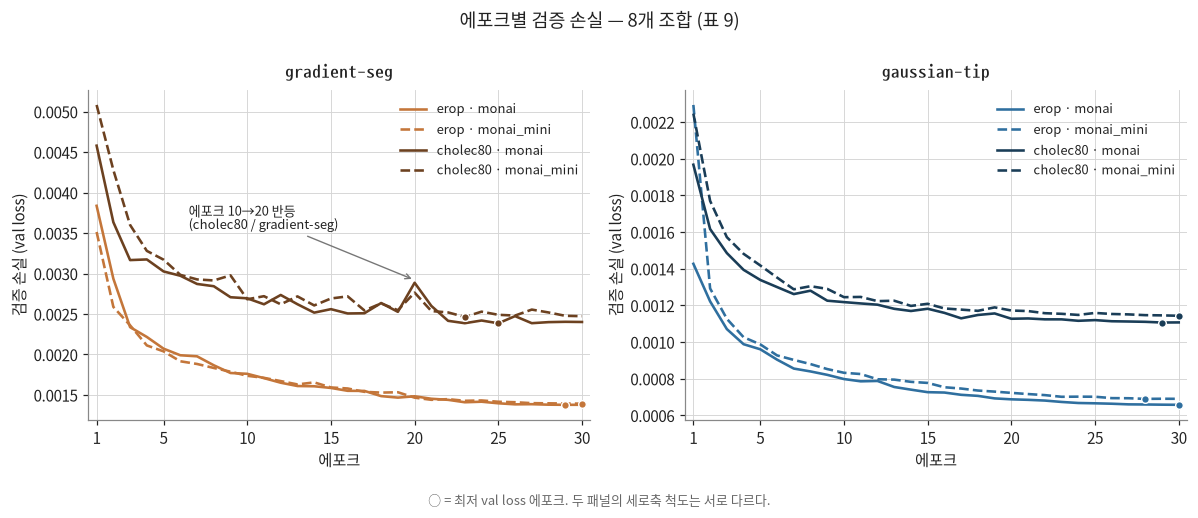

erop/gradient-seg/monai                  best 0.001379 @ epoch 29
erop/gradient-seg/monai_mini             best 0.001393 @ epoch 30
erop/gaussian-tip/monai                  best 0.000658 @ epoch 30
erop/gaussian-tip/monai_mini             best 0.000690 @ epoch 28
cholec80/gradient-seg/monai              best 0.002386 @ epoch 25
cholec80/gradient-seg/monai_mini         best 0.002464 @ epoch 23
cholec80/gaussian-tip/monai              best 0.001107 @ epoch 29
cholec80/gaussian-tip/monai_mini         best 0.001143 @ epoch 30


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.3))

for axis, target_mode in zip(axes, ("gradient-seg", "gaussian-tip")):
    base = COLOR[target_mode]
    for dataset in ("erop", "cholec80"):
        for model_type in ("monai", "monai_mini"):
            epochs, val_losses = read_metric_csv(dataset, target_mode, model_type)
            color = base if dataset == "erop" else mix(base, "#000000", 0.45)
            style = "-" if model_type == "monai" else "--"
            axis.plot(
                epochs, val_losses,
                color=color, linestyle=style, linewidth=1.7,
                label=f"{dataset} · {model_type}",
            )
            best = min(range(len(val_losses)), key=val_losses.__getitem__)
            axis.plot(epochs[best], val_losses[best], "o", color=color, markersize=5,
                      markeredgecolor="white", markeredgewidth=0.9, zorder=5)

    axis.set_title(target_mode, fontfamily="D2Coding", fontweight="bold", pad=8)
    axis.set_xlabel("에포크")
    axis.set_xlim(0.5, 30.5)
    axis.set_xticks([1, 5, 10, 15, 20, 25, 30])
    axis.grid(True, color=GRID, linewidth=0.6)
    axis.set_axisbelow(True)
    for side in ("top", "right"):
        axis.spines[side].set_visible(False)
    axis.legend(frameon=False, fontsize=8.5, loc="upper right")

axes[0].set_ylabel("검증 손실 (val loss)")
axes[1].set_ylabel("검증 손실 (val loss)")
axes[0].annotate(
    "에포크 10→20 반등\n(cholec80 / gradient-seg)",
    xy=(20, 0.00292), xytext=(6.5, 0.00355), fontsize=8.5, color=INK,
    arrowprops=dict(arrowstyle="->", color="#777777", linewidth=0.9),
)
fig.suptitle("에포크별 검증 손실 — 8개 조합 (표 9)", fontsize=12, y=1.0)
fig.text(0.5, -0.045, "○ = 최저 val loss 에포크. 두 패널의 세로축 척도는 서로 다르다.",
         ha="center", fontsize=8.5, color="#666666")
fig.tight_layout()
save(fig, "val-loss-curves")
plt.show()

# 표 9와 대조: 최저 val loss와 그 에포크
for combination in COMBINATIONS:
    epochs, val_losses = read_metric_csv(*combination)
    best = min(range(len(val_losses)), key=val_losses.__getitem__)
    print(f"{'/'.join(combination):<40} best {val_losses[best]:.6f} @ epoch {epochs[best]}")


## 그림 5 — 8개 조합 전체 성능 (표 11)

표 11은 9개 열 × 8개 행이라 축별 패턴(§6.2의 "타겟 방식 ≫ 데이터셋 > 모델 크기")을
눈으로 집어내기 어렵다. Hit@10/20/50은 누적 지표이므로 겹친 막대로 그리면
세 값의 관계와 조합 간 차이를 동시에 읽을 수 있고, 성격이 다른 Miss율과 중앙값 거리는
옆에 따로 붙인다.


findfont: Failed to find font weight bold, now using 600.


saved docs/figures/overall-performance.svg


saved docs/figures/overall-performance.png


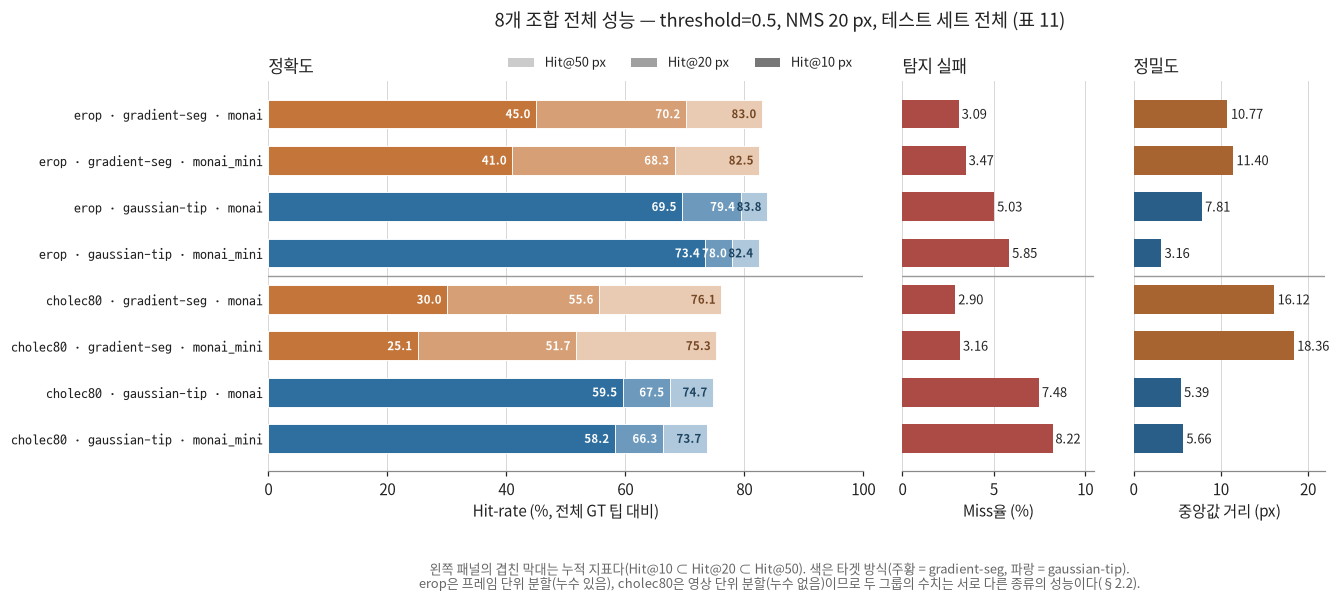

erop/gradient-seg/monai                  miss  3.09 %  hit@10 44.98 %  hit@20 70.17 %  hit@50 82.95 %  median 10.77 px
erop/gradient-seg/monai_mini             miss  3.47 %  hit@10 40.99 %  hit@20 68.28 %  hit@50 82.48 %  median 11.40 px
erop/gaussian-tip/monai                  miss  5.03 %  hit@10 69.52 %  hit@20 79.36 %  hit@50 83.82 %  median  7.81 px
erop/gaussian-tip/monai_mini             miss  5.85 %  hit@10 73.44 %  hit@20 78.00 %  hit@50 82.41 %  median  3.16 px
cholec80/gradient-seg/monai              miss  2.90 %  hit@10 30.04 %  hit@20 55.58 %  hit@50 76.12 %  median 16.12 px
cholec80/gradient-seg/monai_mini         miss  3.16 %  hit@10 25.10 %  hit@20 51.71 %  hit@50 75.29 %  median 18.36 px
cholec80/gaussian-tip/monai              miss  7.48 %  hit@10 59.55 %  hit@20 67.45 %  hit@50 74.72 %  median  5.39 px
cholec80/gaussian-tip/monai_mini         miss  8.22 %  hit@10 58.22 %  hit@20 66.30 %  hit@50 73.70 %  median  5.66 px


In [4]:
def combination_label(dataset: str, target_mode: str, model_type: str) -> str:
    return f"{dataset} · {target_mode} · {model_type}"


rows = list(reversed(COMBINATIONS))      # 위에서부터 표 11 순서가 되도록 뒤집는다
positions = list(range(len(rows)))

fig, axes = plt.subplots(
    1, 3, figsize=(12.4, 4.6), sharey=True,
    gridspec_kw={"width_ratios": [3.1, 1.0, 1.0], "wspace": 0.12},
)
hit_axis, miss_axis, median_axis = axes

for position, combination in zip(positions, rows):
    summary = SUMMARY[combination]
    base = COLOR[combination[1]]
    shades = (mix(base, "#ffffff", 0.62), mix(base, "#ffffff", 0.30), base)
    inks = (mix(base, "#000000", 0.40), "white", "white")
    keys = ("hit_rate_50px_pct", "hit_rate_20px_pct", "hit_rate_10px_pct")
    for shade, ink, key in zip(shades, inks, keys):
        hit_axis.barh(position, summary[key], height=0.62, color=shade, edgecolor="white", linewidth=0.6)
        hit_axis.text(summary[key] - 0.9, position, f"{summary[key]:.1f}",
                      va="center", ha="right", fontsize=7.5, color=ink, fontweight="bold")

    miss_axis.barh(position, summary["miss_rate_pct"], height=0.62, color=COLOR["miss"])
    miss_axis.text(summary["miss_rate_pct"] + 0.15, position, f"{summary['miss_rate_pct']:.2f}",
                   va="center", fontsize=8.5)

    median_axis.barh(position, summary["median_dist_px"], height=0.62, color=mix(base, "#000000", 0.15))
    median_axis.text(summary["median_dist_px"] + 0.4, position, f"{summary['median_dist_px']:.2f}",
                     va="center", fontsize=8.5)

hit_axis.set_yticks(positions)
hit_axis.set_yticklabels([combination_label(*combination) for combination in rows],
                         fontfamily="D2Coding", fontsize=9)
hit_axis.set_ylim(-0.7, len(rows) - 0.3)
hit_axis.set_xlim(0, 100)
hit_axis.set_xlabel("Hit-rate (%, 전체 GT 팁 대비)")
hit_axis.set_title("정확도", loc="left")
miss_axis.set_xlabel("Miss율 (%)")
miss_axis.set_title("탐지 실패", loc="left")
miss_axis.set_xlim(0, 10.5)
median_axis.set_xlabel("중앙값 거리 (px)")
median_axis.set_title("정밀도", loc="left")
median_axis.set_xlim(0, 22)

for axis in axes:
    axis.grid(True, axis="x", color=GRID, linewidth=0.6)
    axis.set_axisbelow(True)
    axis.axhline(3.5, color="#999999", linewidth=0.9)     # erop / cholec80 경계
    axis.tick_params(axis="y", length=0)
    for side in ("top", "right", "left"):
        axis.spines[side].set_visible(False)

legend = [
    mpl.patches.Patch(facecolor=mix("#777777", "#ffffff", 0.62), label="Hit@50 px"),
    mpl.patches.Patch(facecolor=mix("#777777", "#ffffff", 0.30), label="Hit@20 px"),
    mpl.patches.Patch(facecolor="#777777", label="Hit@10 px"),
]
hit_axis.legend(handles=legend, frameon=False, fontsize=8.5, ncol=3,
                loc="lower right", bbox_to_anchor=(1.0, 1.0))

fig.suptitle("8개 조합 전체 성능 — threshold=0.5, NMS 20 px, 테스트 세트 전체 (표 11)",
             fontsize=12, y=1.02)
fig.text(0.5, -0.07,
         "왼쪽 패널의 겹친 막대는 누적 지표다(Hit@10 ⊂ Hit@20 ⊂ Hit@50). "
         "색은 타겟 방식(주황 = gradient-seg, 파랑 = gaussian-tip).\n"
         "erop은 프레임 단위 분할(누수 있음), cholec80은 영상 단위 분할(누수 없음)이므로 "
         "두 그룹의 수치는 서로 다른 종류의 성능이다(§2.2).",
         ha="center", va="top", fontsize=8.5, color="#666666")
save(fig, "overall-performance")
plt.show()

for combination in COMBINATIONS:
    summary = SUMMARY[combination]
    print(f"{'/'.join(combination):<40} miss {summary['miss_rate_pct']:>5.2f} %  "
          f"hit@10 {summary['hit_rate_10px_pct']:>5.2f} %  hit@20 {summary['hit_rate_20px_pct']:>5.2f} %  "
          f"hit@50 {summary['hit_rate_50px_pct']:>5.2f} %  median {summary['median_dist_px']:>5.2f} px")


## 그림 6 — 오차 거리 분포 (표 14)

표 14는 8개 조합 × 8개 구간의 64개 숫자다. 100 % 누적 막대로 그리면
§6.3의 결론 — "두 타겟 방식의 차이는 오차의 *크기*가 아니라 *종류*에 있다" — 이
막대 왼쪽(정밀한 예측)과 오른쪽(긴 꼬리)의 면적 비교로 바로 읽힌다.

기존 그림 7은 이 가운데 두 행만 확대한 것이고, 이 그림은 8개 조합 전체를 한 장에 놓는다.


findfont: Failed to find font weight bold, now using 600.


saved docs/figures/error-distribution-all.svg


saved docs/figures/error-distribution-all.png


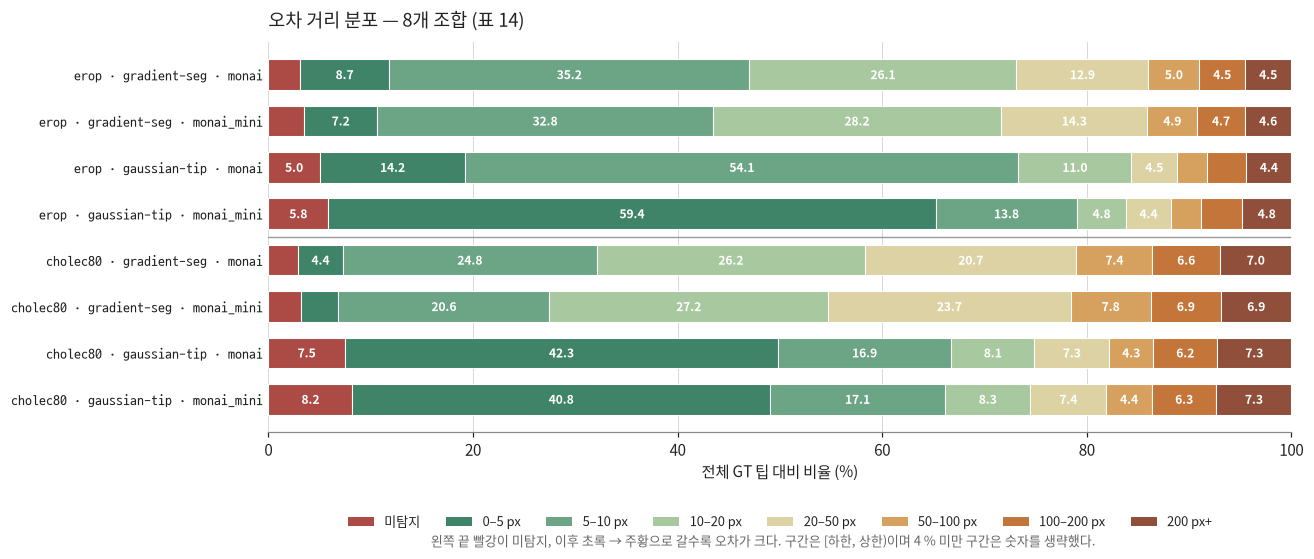

조합                                         miss     0–5 px    5–10 px   10–20 px   20–50 px  50–100 px 100–200 px    200 px+
erop/gradient-seg/monai                    3.09       8.71      35.22      26.10      12.89       4.98       4.47       4.53
erop/gradient-seg/monai_mini               3.47       7.19      32.77      28.21      14.28       4.87       4.66       4.55
erop/gaussian-tip/monai                    5.03      14.22      54.07      11.03       4.49       2.88       3.87       4.40
erop/gaussian-tip/monai_mini               5.85      59.38      13.84       4.76       4.42       2.95       3.98       4.83
cholec80/gradient-seg/monai                2.90       4.39      24.81      26.22      20.68       7.41       6.63       6.97
cholec80/gradient-seg/monai_mini           3.16       3.69      20.63      27.23      23.73       7.81       6.88       6.88
cholec80/gaussian-tip/monai                7.48      42.35      16.91       8.15       7.30       4.31       6.25       7.25


In [5]:
BIN_COLORS = ("#3f8468", "#6ba585", "#a8c8a0", "#ddd2a4", "#d6a15f", "#c4763a", "#8f4f3a")

rows = list(reversed(COMBINATIONS))
positions = list(range(len(rows)))

fig, axis = plt.subplots(figsize=(12.0, 4.6))

for position, combination in zip(positions, rows):
    distribution = PER_TIP[combination]["distribution_pct"]
    left = 0.0
    segments = [("miss", COLOR["miss"])] + [(i, BIN_COLORS[i]) for i in range(len(DISTANCE_LABELS))]
    for key, color in segments:
        value = distribution.get(key, 0.0)
        axis.barh(position, value, left=left, height=0.66, color=color,
                  edgecolor="white", linewidth=0.7)
        if value >= 4.0:
            axis.text(left + value / 2, position, f"{value:.1f}", va="center", ha="center",
                      fontsize=8, color="white", fontweight="bold")
        left += value

axis.set_yticks(positions)
axis.set_yticklabels([f"{d} · {t} · {m}" for d, t, m in rows], fontfamily="D2Coding", fontsize=9)
axis.set_ylim(-0.7, len(rows) - 0.3)
axis.set_xlim(0, 100)
axis.set_xlabel("전체 GT 팁 대비 비율 (%)")
axis.axhline(3.5, color="#999999", linewidth=0.9)
axis.grid(True, axis="x", color=GRID, linewidth=0.6)
axis.set_axisbelow(True)
axis.tick_params(axis="y", length=0)
for side in ("top", "right", "left"):
    axis.spines[side].set_visible(False)

handles = [mpl.patches.Patch(facecolor=COLOR["miss"], label="미탐지")]
handles += [mpl.patches.Patch(facecolor=color, label=label)
            for color, label in zip(BIN_COLORS, DISTANCE_LABELS)]
axis.legend(handles=handles, frameon=False, fontsize=8.5, ncol=8,
            loc="lower center", bbox_to_anchor=(0.5, -0.28))

axis.set_title("오차 거리 분포 — 8개 조합 (표 14)", fontsize=12, loc="left", pad=10)
fig.text(0.5, -0.115,
         "왼쪽 끝 빨강이 미탐지, 이후 초록 → 주황으로 갈수록 오차가 크다. "
         "구간은 [하한, 상한)이며 4 % 미만 구간은 숫자를 생략했다.",
         ha="center", fontsize=8.5, color="#666666")
save(fig, "error-distribution-all")
plt.show()

header = f"{'조합':<40}{'miss':>7}" + "".join(f"{label:>11}" for label in DISTANCE_LABELS)
print(header)
for combination in COMBINATIONS:
    distribution = PER_TIP[combination]["distribution_pct"]
    line = f"{'/'.join(combination):<40}{distribution.get('miss', 0.0):>7.2f}"
    line += "".join(f"{distribution.get(i, 0.0):>11.2f}" for i in range(len(DISTANCE_LABELS)))
    print(line)


## 그림 10 — 도구 수별 헝가리안 FN율 (표 24-2)

§6.7.4가 보고서의 최대 단일 병목으로 지목한 값이다. 표 24-2의 32개 숫자를 선으로 그리면
도구 수에 따른 급증 곡선과 두 데이터셋의 격차가 형태로 드러난다.

`per_tip.csv`의 `hungarian_50px` 열에서 프레임별 GT 팁 수를 세어 다시 계산하므로,
표 24-2와 같은 값이 나와야 한다.


findfont: Failed to find font weight bold, now using 600.


saved docs/figures/hungarian-fn-by-tool-count.svg


saved docs/figures/hungarian-fn-by-tool-count.png


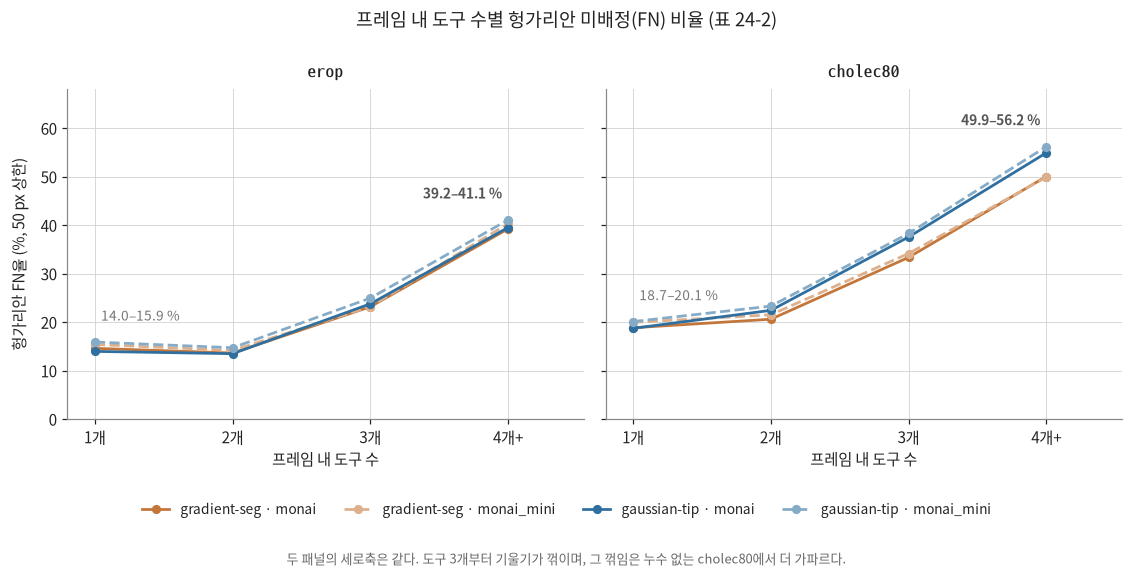

조합                                             1개       2개       3개      4개+
erop/gradient-seg/monai                      14.6     13.6     23.2     39.2
erop/gradient-seg/monai_mini                 15.4     14.2     23.2     40.3
erop/gaussian-tip/monai                      14.0     13.5     23.8     39.5
erop/gaussian-tip/monai_mini                 15.9     14.7     24.9     41.1
cholec80/gradient-seg/monai                  18.8     20.6     33.3     50.0
cholec80/gradient-seg/monai_mini             19.9     21.5     34.2     49.9
cholec80/gaussian-tip/monai                  18.7     22.4     37.5     54.9
cholec80/gaussian-tip/monai_mini             20.1     23.3     38.3     56.2


In [6]:
TOOL_LABELS = {1: "1개", 2: "2개", 3: "3개", 4: "4개+"}
x_positions = [1, 2, 3, 4]

fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.3), sharey=True)

for axis, dataset in zip(axes, ("erop", "cholec80")):
    first, last = [], []
    for target_mode in ("gradient-seg", "gaussian-tip"):
        for model_type in ("monai", "monai_mini"):
            rates = PER_TIP[(dataset, target_mode, model_type)]["fn_rate_pct"]
            values = [rates[key] for key in x_positions]
            first.append(values[0])
            color = COLOR[target_mode] if model_type == "monai" else mix(COLOR[target_mode], "#ffffff", 0.42)
            axis.plot(x_positions, values, marker="o", markersize=5, linewidth=1.8,
                      linestyle="-" if model_type == "monai" else "--",
                      color=color, label=f"{target_mode} · {model_type}")
            last.append(values[-1])

    # 네 조합의 4개+ 값이 거의 겹치므로 개별 라벨 대신 범위를 한 번만 적는다.
    axis.annotate(f"{min(last):.1f}–{max(last):.1f} %", xy=(4, max(last)), xytext=(-4, 14),
                  textcoords="offset points", ha="right", fontsize=9, fontweight="bold",
                  color="#555555")
    axis.annotate(f"{min(first):.1f}–{max(first):.1f} %", xy=(1, max(first)), xytext=(4, 14),
                  textcoords="offset points", ha="left", fontsize=9, color="#777777")

    axis.set_title(dataset, fontfamily="D2Coding", fontweight="bold", pad=8)
    axis.set_xticks(x_positions)
    axis.set_xticklabels([TOOL_LABELS[key] for key in x_positions])
    axis.set_xlim(0.8, 4.55)
    axis.set_xlabel("프레임 내 도구 수")
    axis.grid(True, color=GRID, linewidth=0.6)
    axis.set_axisbelow(True)
    for side in ("top", "right"):
        axis.spines[side].set_visible(False)

axes[0].set_ylim(0, 68)
axes[0].set_ylabel("헝가리안 FN율 (%, 50 px 상한)", labelpad=8)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, fontsize=9, ncol=4,
           loc="lower center", bbox_to_anchor=(0.5, -0.10))

fig.suptitle("프레임 내 도구 수별 헝가리안 미배정(FN) 비율 (표 24-2)", fontsize=12, y=1.0)
fig.text(0.5, -0.17,
         "두 패널의 세로축은 같다. 도구 3개부터 기울기가 꺾이며, 그 꺾임은 "
         "누수 없는 cholec80에서 더 가파르다.",
         ha="center", fontsize=8.5, color="#666666")
fig.tight_layout()
save(fig, "hungarian-fn-by-tool-count")
plt.show()

print(f"{'조합':<40}" + "".join(f"{TOOL_LABELS[key]:>9}" for key in x_positions))
for combination in COMBINATIONS:
    rates = PER_TIP[combination]["fn_rate_pct"]
    print(f"{'/'.join(combination):<40}" + "".join(f"{rates[key]:>9.1f}" for key in x_positions))


## 그림 12 — 분할 방식별 성능 변화 (표 29·30)

`cholec80`은 같은 프레임 집합·같은 학습 설정에서 프레임 단위와 영상 단위 두 분할로
학습·평가된 결과를 모두 갖는다(§11.3). 표 29는 화살표 표기(`a → b`)로 그 변화를 적었는데,
슬로프 차트로 그리면 "네 조합 전부, 모든 지표에서 같은 방향으로 나빠졌다"는 것이
선의 기울기로 즉시 보인다.

구 분할 결과는 `data/results/cholec80-frame-split/`에 보존되어 있다.


saved docs/figures/split-unit-comparison.svg


saved docs/figures/split-unit-comparison.png


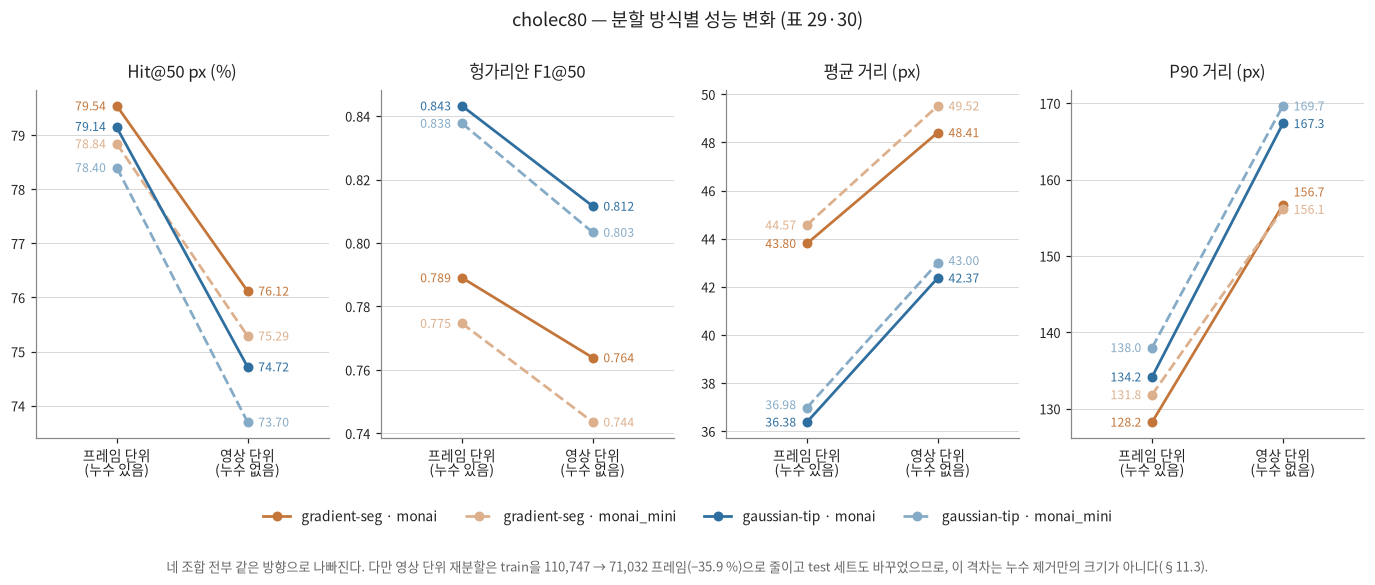

gradient-seg/monai
  Hit@50 px (%): 79.540 → 76.120  헝가리안 F1@50: 0.789 → 0.764  평균 거리 (px): 43.800 → 48.410  P90 거리 (px): 128.250 → 156.660
gradient-seg/monai_mini
  Hit@50 px (%): 78.840 → 75.290  헝가리안 F1@50: 0.775 → 0.744  평균 거리 (px): 44.570 → 49.520  P90 거리 (px): 131.840 → 156.110
gaussian-tip/monai
  Hit@50 px (%): 79.140 → 74.720  헝가리안 F1@50: 0.843 → 0.812  평균 거리 (px): 36.380 → 42.370  P90 거리 (px): 134.170 → 167.340
gaussian-tip/monai_mini
  Hit@50 px (%): 78.400 → 73.700  헝가리안 F1@50: 0.838 → 0.803  평균 거리 (px): 36.980 → 43.000  P90 거리 (px): 138.000 → 169.650


In [7]:
FRAME_SPLIT_ROOT = RESULTS_ROOT / "cholec80-frame-split"

METRICS = (
    ("hit_rate_50px_pct", "Hit@50 px (%)", "%.2f"),
    ("f1_50", "헝가리안 F1@50", "%.3f"),
    ("mean_dist_px", "평균 거리 (px)", "%.2f"),
    ("p90_dist_px", "P90 거리 (px)", "%.1f"),
)


def metric_value(summary: dict, key: str) -> float:
    if key == "f1_50":
        return summary["hungarian"]["distance_caps_px"]["50"]["f1"]
    return summary[key]


# 구 프레임 분할 결과는 data/results/cholec80-frame-split/<타겟>/<모델>/ 아래에 보존되어 있다.
split_pairs = {}
for target_mode in ("gradient-seg", "gaussian-tip"):
    for model_type in ("monai", "monai_mini"):
        old = json.loads(
            (FRAME_SPLIT_ROOT / target_mode / model_type / "summary.json").read_text(encoding="utf-8")
        )
        split_pairs[(target_mode, model_type)] = (old, SUMMARY[("cholec80", target_mode, model_type)])

fig, axes = plt.subplots(1, 4, figsize=(12.6, 4.4))

for axis, (key, title, fmt) in zip(axes, METRICS):
    endpoints = {}
    for (target_mode, model_type), (old, new) in split_pairs.items():
        color = COLOR[target_mode] if model_type == "monai" else mix(COLOR[target_mode], "#ffffff", 0.42)
        values = (metric_value(old, key), metric_value(new, key))
        endpoints[(target_mode, model_type)] = (values, color)
        axis.plot([0, 1], values, marker="o", markersize=5.5, linewidth=1.8, color=color,
                  linestyle="-" if model_type == "monai" else "--",
                  label=f"{target_mode} · {model_type}")

    # 값이 거의 같은 두 조합의 라벨이 겹치지 않도록 세로 위치만 살짝 벌린다.
    span = max(max(values) for values, _ in endpoints.values()) - min(
        min(values) for values, _ in endpoints.values()
    )
    for side, (x, offset, align) in enumerate(((0, -7, "right"), (1, 7, "left"))):
        keys = list(endpoints)
        raw = [endpoints[key][0][side] for key in keys]
        for key, value, placed in zip(keys, raw, spread(raw, span * 0.055)):
            axis.annotate(fmt % value, xy=(x, placed), xytext=(offset, 0),
                          textcoords="offset points", ha=align, va="center",
                          fontsize=8, color=endpoints[key][1])

    axis.set_title(title, pad=8)
    axis.set_xlim(-0.62, 1.62)
    axis.set_xticks([0, 1])
    axis.set_xticklabels(["프레임 단위\n(누수 있음)", "영상 단위\n(누수 없음)"], fontsize=9)
    axis.grid(True, axis="y", color=GRID, linewidth=0.6)
    axis.set_axisbelow(True)
    axis.tick_params(axis="y", labelsize=8.5)
    for side in ("top", "right"):
        axis.spines[side].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, fontsize=9, ncol=4, loc="lower center", bbox_to_anchor=(0.5, -0.09))

fig.suptitle("cholec80 — 분할 방식별 성능 변화 (표 29·30)", fontsize=12, y=1.0)
fig.text(0.5, -0.16,
         "네 조합 전부 같은 방향으로 나빠진다. 다만 영상 단위 재분할은 train을 "
         "110,747 → 71,032 프레임(−35.9 %)으로 줄이고 test 세트도 바꾸었으므로, "
         "이 격차는 누수 제거만의 크기가 아니다(§11.3).",
         ha="center", fontsize=8.5, color="#666666")
fig.tight_layout()
save(fig, "split-unit-comparison")
plt.show()

for (target_mode, model_type), (old, new) in split_pairs.items():
    changes = "  ".join(
        f"{title}: {metric_value(old, key):.3f} → {metric_value(new, key):.3f}"
        for key, title, _ in METRICS
    )
    print(f"{target_mode}/{model_type}\n  {changes}")


## 생성된 파일

아래 다섯 쌍이 `docs/figures/`에 저장되었다. SVG가 원본이고 PNG(192 dpi)를 보고서가 링크한다.
파일 이름은 고정되어 있으므로 이 노트북을 다시 실행하면 같은 자리에 덮어쓰이고,
`docs/final-report.md`의 그림 링크는 수정할 필요가 없다.


In [8]:
for name in ("val-loss-curves", "overall-performance", "error-distribution-all",
             "hungarian-fn-by-tool-count", "split-unit-comparison"):
    for suffix in ("svg", "png"):
        path = FIGURE_DIR / f"{name}.{suffix}"
        print(f"{path.relative_to(REPO_ROOT)!s:<50}{path.stat().st_size / 1024:>8.1f} KB")


docs/figures/val-loss-curves.svg                      40.4 KB
docs/figures/val-loss-curves.png                     217.1 KB
docs/figures/overall-performance.svg                  36.2 KB
docs/figures/overall-performance.png                 197.6 KB
docs/figures/error-distribution-all.svg               41.4 KB
docs/figures/error-distribution-all.png              159.6 KB
docs/figures/hungarian-fn-by-tool-count.svg           28.4 KB
docs/figures/hungarian-fn-by-tool-count.png          157.5 KB
docs/figures/split-unit-comparison.svg                46.4 KB
docs/figures/split-unit-comparison.png               298.2 KB
